# Brightify: a step-by-step brightness-map tutorial

This tutorial notebook downloads the example MCPL input from [Zenodo record 15537265](https://doi.org/10.5281/zenodo.15537265), selects neutrons in the same energy interval, calculates brightness and relative uncertainty over the surface, and plots both maps. The compressed MCPL file is about 459 MiB. Loading and scanning it can take several minutes and requires substantial free memory. The notebook stores the downloaded file in your home directory's cache. You need an internet connection for the download and initial package installation.

> The Zenodo dataset is licensed [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). Please cite the dataset and Brightify's [research paper](https://doi.org/10.1016/j.nima.2025.171037) when using them in research.

## Start importing Brightify

`Flat` is Brightify's model for particles crossing a flat surface, which is the case of the provided MCPL file. Let's import it as follows

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import Brightify
from Brightify import Flat
import os

## Download and verify the sample MCPL file

The record contains one file, `output.mcpl.gz` (480,756,300 bytes). We will use `zenodo_get` to obtain the data from the Zenodo repository. This may take a while.

In [19]:
!zenodo_get -d https://doi.org/10.5281/zenodo.15537265 -v 0 -o $HOME/.cache/. --no-overwrite

## Set the calculation parameters

These values match the `Flat(...)` call in `verification.py`:

- `primary_protons`: number of source primary protons used for normalization (47 million for this example).
- `pCurrent`: source particle current. The example uses `1.0`; replace it with the current appropriate to your simulation when analyzing your own data.
- `pos_size_x` and `pos_size_y`: width and height of the spatial sampling window. The example uses a 1 cm by 1 cm window; map axes in this example are labeled in cm.
- `dir_size`: angular-window size used to select particles around each calculation direction. The example value is `6e-3` (steradians).

These are analysis/normalization inputs, not values inferred from the downloaded file. Use the normalization that matches the simulation that produced your MCPL file.

In [47]:
PRIMARY_PROTONS = 47_000_000
PARTICLE_CURRENT = 1.0
POSITION_WINDOW_X = 1.0
POSITION_WINDOW_Y = 1.0
DIRECTION_WINDOW = 6e-3
DATA_FILE = f"{os.getenv('HOME')}/.cache/output.mcpl.gz"
flat_model = Flat(
    inputFile=str(DATA_FILE),
    primary_protons=PRIMARY_PROTONS,
    pCurrent=PARTICLE_CURRENT,
    pos_size_x=POSITION_WINDOW_X,
    pos_size_y=POSITION_WINDOW_Y,
    dir_size=DIRECTION_WINDOW,
)

print(f"Loaded {len(flat_model.data):,} particles")
flat_model.data.head()

Loaded 21,580,959 particles


,Kf,x,y,z,Vx,Vy,Vz,e,Wt
0,2112,-0.162481,-0.040676,0.06,-0.660523,0.190048,0.726355,2.500000e-08,1.0
1,2112,-0.029267,-0.583007,0.06,-0.547038,-0.737882,0.395322,2.500000e-08,1.0
2,2112,0.011129,0.043405,0.06,-0.497699,0.456605,0.737433,2.500000e-08,1.0
3,2112,0.215334,0.099948,0.06,0.123330,0.753316,0.645991,2.500000e-08,1.0
4,2112,0.276657,-0.141431,0.06,0.950695,0.016866,0.309668,2.500000e-08,1.0


Brightify reads MCPL particle records into a table. `Kf` is the particle PDG code, `e` is the kinetic energy stored in the MCPL file, `Wt` is particle weight, `x`/`y`/`z` are position, and `Vx`/`Vy`/`Vz` are direction cosines. Inspect the table before changing filters; confirm the energy convention used by the simulation that wrote your MCPL file.

In [48]:
flat_model.data[["Kf", "e", "Wt", "x", "y", "z", "Vx", "Vy", "Vz"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Kf,21580959.0,2.112000e+03,0.000000e+00,2.112000e+03,2.112000e+03,2.112000e+03,2.112000e+03,2.112000e+03
e,21580959.0,2.500000e-08,0.000000e+00,2.500000e-08,2.500000e-08,2.500000e-08,2.500000e-08,2.500000e-08
Wt,21580959.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
x,21580959.0,2.109775e-05,2.901604e-01,-9.999976e-01,-1.799338e-01,5.307291e-05,1.799747e-01,9.999966e-01
y,21580959.0,-5.635878e-07,2.901545e-01,-9.999995e-01,-1.800625e-01,2.764681e-05,1.800592e-01,9.999971e-01
z,21580959.0,6.000000e-02,3.345598e-09,6.000000e-02,6.000000e-02,6.000000e-02,6.000000e-02,6.000000e-02
Vx,21580959.0,4.754960e-06,5.644895e-01,-9.990082e-01,-4.868726e-01,5.954529e-05,4.868599e-01,9.988768e-01
Vy,21580959.0,-2.261188e-04,5.644903e-01,-9.991798e-01,-4.872134e-01,-2.883829e-04,4.867138e-01,9.989373e-01
Vz,21580959.0,5.403951e-01,2.658484e-01,3.187988e-02,3.109781e-01,5.408073e-01,7.704859e-01,1.000000e+00


## Filter the particle population

The verification example keeps neutrons and applies an inclusive energy interval of 0 to 2 in the energy values stored in the MCPL records. `apply_filter` narrows the model's current filter; it does not delete the original particle records. For another simulation, use the desired particle species and energy limits in the units used by its MCPL data.

In [49]:
flat_model.apply_filter?

Signature: flat_model.apply_filter(particle=None, energy=None, x=None, y=None)
Docstring:
Applies filters to the particle data based on the given criteria:
- particle: Type of particle (e.g., 'proton', 'neutron')
- energy: Energy range to filter particles by
- x: x-position range to filter particles by
- y: y-position range to filter particles by
File:      ~/repos/Brightify/Brightify/main.py
Type:      method

In [51]:
flat_model.apply_filter(
    particle="neutron",
    x=(0,0.1),
)

filtered_particles = flat_model.data_filter
print(f"Selected {len(filtered_particles):,} of {len(flat_model.data):,} particles")
print(f"Sum of selected particle weights: {filtered_particles['Wt'].sum():,.6g}")

Selected 3,177,649 of 21,580,959 particles
Sum of selected particle weights: 3.17765e+06


## Calculate brightness and uncertainty

`calculate` lays out a spatial grid and evaluates particles in each position window. This tutorial explicitly chooses `method="mean"`: at each grid point, Brightify calculates a weighted mean direction and counts the particle weight within the configured angular window around it. That yields a normalized brightness array (`flat_model.brightness`) and a relative-error array (`flat_model.relative_error`).

`verification.py` calls `calculate()` without arguments, which selects Brightify's `adaptive` method. The adaptive method searches angular histogram maxima instead. This notebook deliberately uses `mean` for its main maps: in the current implementation, the adaptive brightness plot displays unnormalized accepted weights, and the adaptive error-plot branch creates an all-undefined map. Using `mean` makes both tutorial plots use the populated, normalized brightness and relative-error arrays. Calculation can take a while because the map scans many overlapping position windows.

In [52]:
flat_model.calculate(method="mean")

print(f"Spatial grid: {len(flat_model.x_range)} x {len(flat_model.y_range)} points")
print(f"Finite brightness values: {np.isfinite(flat_model.brightness).sum():,}")
print(f"Finite relative-error values: {np.isfinite(flat_model.relative_error).sum():,}")

common: 100%|##########| 60/60 [00:01<00:00, 42.83it/s]

Spatial grid: 5 x 12 points
Finite brightness values: 30
Finite relative-error values: 30


## Plot the brightness map

The color at each map position represents the calculated brightness; the direction arrows show the mean particle direction in that position window. Brightify labels brightness in `n/s/cm²/sr`. Interpret its absolute scale using the source current and number of primary protons supplied above. Empty spatial windows have no estimate and appear blank.

In [53]:
flat_model.plot_brightness_map?

Signature: flat_model.plot_brightness_map(method=None, show_arrows=True)
Docstring:
Plot brightness map with optional auto-detection of method
and arrows for direction vectors.

method: "mean", "adaptive", "normal", or None (auto-detect)
show_arrows: whether to draw direction arrows
File:      ~/repos/Brightify/Brightify/main.py
Type:      method

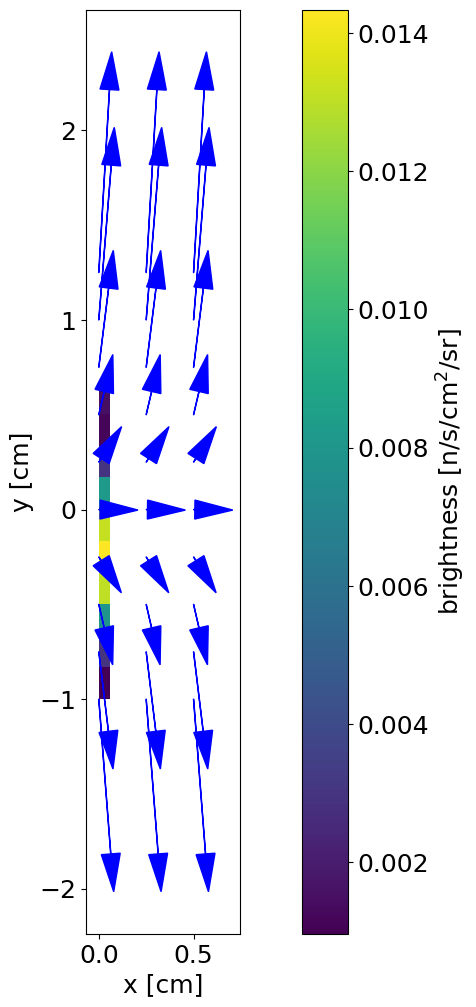

In [54]:
flat_model.plot_brightness_map(method="mean")

## Plot the relative-error map

The relative-error map helps identify positions whose brightness estimates have greater statistical uncertainty. It uses the relative errors calculated in the preceding step; low-statistics or empty windows may be undefined. Arrows again show the mean direction at each position.

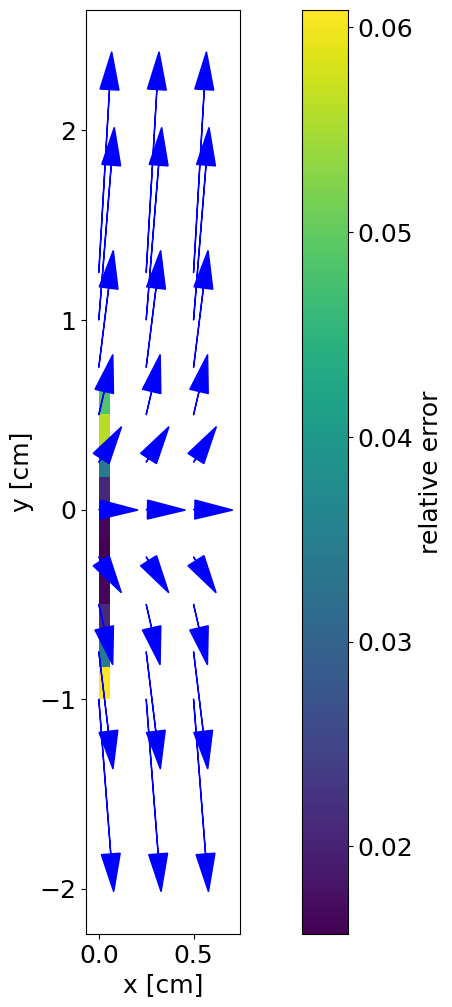

In [55]:
flat_model.plot_error_map(method="mean")